## Entity-sentiment pipeline: Wave 1 + Wave 2 fixes

Notebook 2.0 built the sentence-level entity tagging and FinBERT sentiment pipeline and used it to score the full TSLA corpus. It also documented five concrete weaknesses found by eyeballing the actual output rather than synthetic examples: anaphora antecedent hijacking by incidental mentions (article 139579101, "Lucid's market debut ... led by Peter Rawlinson, Tesla's former chief vehicle engineer" flipped the antecedent from Lucid to Tesla), promo-question hijacking ("Missed Nvidia and Tesla?"), comparison-sentence contamination ("Build-A-Bear outperformed Tesla" scored positive and got credited to Tesla, driving roughly 4 of the top-10 most-positive articles), boilerplate sentences longer than 20 characters scoring like real content, and a metric bug in the CEO-mention ablation (an outer join left NaN baselines for articles that only gained target sentences via CEO mentions, and `.abs().mean()` silently dropped exactly those rows).

Since 2.0, two waves of changes landed in `stock_predictor/config.py`, `stock_predictor/text/entity_filter.py`, and `stock_predictor/text/sentiment.py`:

- **Wave 1 -- algorithm fixes.** `mentions_target`/`mentions_other` are now computed independently instead of an if/elif (which hid every both-company sentence), with a new `is_comparative` flag for sentences naming both. Antecedent updates now skip question sentences and resolve first-mention-wins when several companies appear in one sentence. Bare "it" was removed from `GENERIC_ANAPHORA` (it matched any sentence containing "it", not just the anaphoric case); only sentence-initial "It"/"Its" fires the anaphora path now. A new `flag_boilerplate()` pass excludes corpus-repeated sentences from aggregates. `aggregate_article_features` gained `sent_entity_excl_comp_*` (target mean excluding comparative sentences), `sent_ceo_*` (CEO-only sentences), and comparative/boilerplate/CEO sentence counts.
- **Wave 2 -- ticker-agnostic registry refactor.** The old target-relative `ALIASES`/`OTHER_COMPANIES` split is replaced by one symmetric `COMPANIES` registry (20 entries) so the pipeline works for any ticker -- Tesla is correctly an "other company" when the target is NVDA, which the old split could not express.

This notebook documents both waves with rationale and a demonstration against the real failure cases, re-runs the full pipeline over the same 2,124-article corpus, and measures before vs. after against 2.0's own numbers. It does not re-derive the fixes -- those are settled and live in the modules; this is the record of what changed and what it did.

**Inputs:** `data/processed/processed_articles.parquet` (unchanged since 1.2), plus the *existing* `data/sentences.parquet` and `data/articles.parquet` -- 2.0's pre-fix run, used here as the "before" snapshot.

**Outputs:** those same two files, overwritten in place with the post-fix run.


### 0. Loading the corpus and the pre-fix snapshot

`data/sentences.parquet` and `data/articles.parquet` are about to be overwritten by this notebook's own re-run in section 5. To keep a stable "before" snapshot across re-executions, the first run below copies them to `data/interim/sentences_before_2.1.parquet` / `articles_before_2.1.parquet`; any later re-run loads from those copies instead of the (by then post-fix) live files.


In [1]:
import time

import pandas as pd
import matplotlib.pyplot as plt

from stock_predictor.config import (
    DATA_DIR,
    INTERIM_DATA_DIR,
    PROCESSED_DATA_DIR,
    PRIMARY_TICKER,
)
from stock_predictor.text import entity_filter, sentiment

pd.set_option("display.max_colwidth", 200)

articles = pd.read_parquet(PROCESSED_DATA_DIR / "processed_articles.parquet")
print(articles.shape)

before_sentences_path = INTERIM_DATA_DIR / "sentences_before_2.1.parquet"
before_articles_path = INTERIM_DATA_DIR / "articles_before_2.1.parquet"

if not before_sentences_path.exists():
    pd.read_parquet(DATA_DIR / "sentences.parquet").to_parquet(before_sentences_path, index=False)
if not before_articles_path.exists():
    pd.read_parquet(DATA_DIR / "articles.parquet").to_parquet(before_articles_path, index=False)

sentences_before = pd.read_parquet(before_sentences_path)
articles_before = pd.read_parquet(before_articles_path)
print("sentences_before:", sentences_before.shape, list(sentences_before.columns))
print("articles_before:", articles_before.shape)


2026-08-15 12:16:45.160 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: D:\ML\stock-predictor


(2124, 8)


sentences_before: (71410, 11) ['article_id', 'sent_idx', 'text', 'mentions_target', 'mentions_other', 'mentions_ceo', 'resolved_by_anaphora', 'char_len', 'pos', 'neg', 'neu']
articles_before: (2124, 25)


In [2]:
before_tag_cols = [c for c in ["mentions_target", "mentions_other", "mentions_ceo", "resolved_by_anaphora"] if c in sentences_before.columns]
sentences_before[before_tag_cols].mean().rename("share of all sentences (BEFORE fixes)")


mentions_target         0.211945
mentions_other          0.099818
mentions_ceo            0.055594
resolved_by_anaphora    0.068618
Name: share of all sentences (BEFORE fixes), dtype: float64

## 1. Wave 1a -- anaphora antecedent hijacking (the Lucid case)

2.0 section 1.4 found the canonical failure case in article 139579101, a Lucid-focused piece: "Lucid's market debut ... was led by Peter Rawlinson, Tesla's former chief vehicle engineer." The old code tracked a single antecedent slot and always handed it to the target on any target mention in a sentence, so this incidental possessive "Tesla's" flipped the antecedent and mistagged the Lucid sentences that followed as being about Tesla.

The fix has two parts. `mentions_target`/`mentions_other` are now computed independently rather than an if/elif, so a sentence naming both companies gets both flags instead of only the target's. And the antecedent-update rule changed to first-mention-wins when several companies are named in one sentence: English news prose puts the grammatical subject/topic first, while an incidental mention like "led by X, Tesla's former engineer" sits in a trailing subordinate clause. We re-tag this article's real text below with the fixed code and compare the same rows against the pre-fix `sentences_before` snapshot.


In [3]:
lucid_row = articles.loc[articles.article_id == 139579101].iloc[0]
print(lucid_row["headline"])

nlp = entity_filter._get_nlp()
lucid_sents = entity_filter.split_sentences([lucid_row["processed_body"]], nlp=nlp)[0]
lucid_tagged_after = entity_filter.tag_sentences(139579101, lucid_sents, PRIMARY_TICKER)

raw_matches = lucid_tagged_after.index[lucid_tagged_after["text"].str.contains("Rawlinson", na=False)]
raw_idx = raw_matches[0]
window_after = lucid_tagged_after.iloc[raw_idx: raw_idx + 6][
    ["sent_idx", "text", "mentions_target", "mentions_other", "resolved_by_anaphora"]
]
window_after


2 Things Every Lucid (LCID) Investor Needs to Know
2026-08-15 12:16:52.783 | INFO     | stock_predictor.text.entity_filter:_get_nlp:62 - Loading spaCy model 'en_core_web_sm' (excluding ner, lemmatizer)


,sent_idx,text,mentions_target,mentions_other,resolved_by_anaphora
4,4,"Lucid's market debut attracted lots of attention because it was led by Peter Rawlinson, Tesla 's ( TSLA +3.80% ) former chief vehicle engineer.",True,True,False
5,5,"In its pre-merger presentation, it claimed it could deliver 20,000 vehicles in 2022, 49,000 in 2023, and 90,000 in 2024.",False,False,False
6,6,"Its first vehicle was the Air sedan, and it planned to launch its second vehicle, the Gravity SUV, in 2023.",False,True,True
7,7,"But in reality, it only delivered 4,369 vehicles in 2022, 6,001 in 2023, and 10,241 in 2024.",False,False,False
8,8,"It postponed the Gravity's launch from late 2023 to late 2024, and Rawlinson stepped down in 2025.",False,True,True
9,9,"On the bright side, its deliveries rose 55% to 15,841 vehicles in 2025 as it ramped up its production of the Gravity, and it expects to produce 25,000 to 27,000 vehicles in 2026.",False,False,False


In [4]:
before_rows = sentences_before[sentences_before.article_id == 139579101]
before_cols = ["sent_idx", "text", "mentions_target", "mentions_other"]
if "resolved_by_anaphora" in before_rows.columns:
    before_cols.append("resolved_by_anaphora")
window_before = before_rows[before_rows.sent_idx.isin(window_after["sent_idx"])][before_cols]
print("BEFORE (2.0, pre-fix) -- same sentence window:")
window_before


BEFORE (2.0, pre-fix) -- same sentence window:


,sent_idx,text,mentions_target,mentions_other,resolved_by_anaphora
36718,4,"Lucid's market debut attracted lots of attention because it was led by Peter Rawlinson, Tesla 's ( TSLA +3.80% ) former chief vehicle engineer.",True,False,False
36719,5,"In its pre-merger presentation, it claimed it could deliver 20,000 vehicles in 2022, 49,000 in 2023, and 90,000 in 2024.",True,False,True
36720,6,"Its first vehicle was the Air sedan, and it planned to launch its second vehicle, the Gravity SUV, in 2023.",True,False,True
36721,7,"But in reality, it only delivered 4,369 vehicles in 2022, 6,001 in 2023, and 10,241 in 2024.",True,False,True
36722,8,"It postponed the Gravity's launch from late 2023 to late 2024, and Rawlinson stepped down in 2025.",True,False,True
36723,9,"On the bright side, its deliveries rose 55% to 15,841 vehicles in 2025 as it ramped up its production of the Gravity, and it expects to produce 25,000 to 27,000 vehicles in 2026.",True,False,True


The window around the Rawlinson sentence (sent_idx 4-9) flips from uniformly wrong to correctly attributed. Before the fix, all six sentences carry `mentions_target=True, mentions_other=False` -- the Rawlinson mention at sent_idx 4 hijacked the antecedent to Tesla, and every subsequent "its"/"it" sentence (Lucid's pre-merger targets, the Air sedan, delivery misses, the Gravity delay) inherited that wrong antecedent via the old promiscuous bare-"it" rule.

After the fix: sent_idx 4 (the sentence that actually names both companies) correctly gets both `mentions_target=True` and `mentions_other=True` -- first-mention-wins puts the antecedent on Lucid, since "Lucid's market debut" leads the sentence and "Tesla's former chief vehicle engineer" is the trailing incidental mention. Sent_idx 6 and 8 (sentence-initial "Its"/"It") correctly resolve via anaphora to `mentions_other=True` (Lucid), not target. Sent_idx 5, 7, and 9 -- which contain bare, non-sentence-initial "it"/"its" ("it claimed it could deliver...", "it only delivered...", "its deliveries rose...") -- now get no attribution at all rather than a wrong one, since bare "it" no longer fires anaphora. That's a real tradeoff: we traded five wrongly-Tesla-tagged sentences for two correctly-Lucid-tagged sentences and three now-unattributed sentences, which is the right direction (fewer wrong labels) even though it leaves some real Lucid signal on the table.

In plain terms: this is the exact broken example from 2.0 -- a Lucid article that used to get mislabeled as being about Tesla right after mentioning Tesla's former engineer -- and the fix genuinely closes it. The two sentences that most clearly continue talking about Lucid ("Its first vehicle...", "It postponed the Gravity's launch...") now correctly point back to Lucid, not Tesla. A few other sentences that also *should* be about Lucid no longer get any attribution at all, since the fix that stops the Tesla-hijack also removes the (previously too-aggressive) way those specific sentences used to get picked up.


## 2. Wave 1b -- question hijacking and bare "it"

Two more antecedent-corruption patterns 2.0 flagged qualitatively without a repro: promo/rhetorical questions like "Missed Nvidia and Tesla?" that name companies without establishing an actual topic, and bare "it" matching anywhere in a sentence ("it is worth noting", "make it") rather than only the genuinely anaphoric sentence-initial position. Both fixes live in `resolve_anaphora()`: a sentence ending in "?" no longer updates the antecedent (its own `mentions_target`/`mentions_other` flags are still set), and `GENERIC_ANAPHORA` no longer contains bare "it" -- only sentence-initial "It"/"Its" triggers the anaphora path now. We hand-build small sentence sequences to demonstrate both in isolation, since neither pattern has a single clean real-corpus example as self-contained as the Lucid case.


In [5]:
question_demo = [
    "Tesla reported strong deliveries this quarter.",
    "Missed Nvidia and Tesla? Here are five other stocks to watch instead.",
    "The company plans to expand its lineup next year.",
]
entity_filter.tag_sentences("demo_question", question_demo, PRIMARY_TICKER)[
    ["sent_idx", "text", "mentions_target", "mentions_other", "is_comparative", "resolved_by_anaphora"]
]


,sent_idx,text,mentions_target,mentions_other,is_comparative,resolved_by_anaphora
0,0,Tesla reported strong deliveries this quarter.,True,False,False,False
1,1,Missed Nvidia and Tesla? Here are five other stocks to watch instead.,True,True,True,False
2,2,The company plans to expand its lineup next year.,False,True,False,True


Sentence 1 names both Tesla and Nvidia and is correctly flagged `is_comparative`, but because it ends in "?" it does not update the antecedent -- so sentence 2's "the company" still resolves to Tesla (set by sentence 0), not Nvidia, which is what a naive first-mention-wins-on-every-sentence rule would have produced.


In [6]:
it_demo = [
    "Tesla delivered record numbers this quarter.",
    "Analysts said it was hard to believe the pace could continue.",
    "It also raised prices across its lineup.",
]
entity_filter.tag_sentences("demo_it", it_demo, PRIMARY_TICKER)[
    ["sent_idx", "text", "mentions_target", "mentions_other", "resolved_by_anaphora"]
]


,sent_idx,text,mentions_target,mentions_other,resolved_by_anaphora
0,0,Tesla delivered record numbers this quarter.,True,False,False
1,1,Analysts said it was hard to believe the pace could continue.,False,False,False
2,2,It also raised prices across its lineup.,True,False,True


Sentence 1's bare, mid-sentence "it" ("said it was hard to believe") no longer fires anaphora -- under the old `GENERIC_ANAPHORA` entry it would have matched and been mistagged as a Tesla sentence. Sentence 2's sentence-initial "It" still resolves correctly, since that is the genuinely anaphoric position.

In plain terms: the old rule treated the word "it" anywhere in a sentence as a reference back to whichever company was last named, which is wrong most of the time in ordinary prose ("it is worth noting" is not about Tesla). Now only a sentence that actually starts with "It" or "Its" gets treated that way, and a company-naming sentence that merely asks a question doesn't get to redirect what "it" means for everything that follows.


## 3. Wave 1c -- comparative-sentence contamination

2.0 section 3.1 found roughly 4 of the top-10 most-positive articles were driven by sentences like "Build-A-Bear outperformed Tesla" -- genuinely positive text, but about the OTHER company, not the target. FinBERT scores at the sentence level, not the entity level, so the whole sentence's positive score got credited to Tesla. `is_comparative` now flags any sentence where the target and another company are both named explicitly, and `aggregate_article_features` adds a comparative-excluded target mean (`sent_entity_excl_comp_*`) alongside the plain one, rather than the tagger silently picking a side.


In [7]:
comp_demo = [
    "Build-A-Bear outperformed Tesla and Micron this year, delivering triple-digit returns.",
    "Tesla shares fell after the recall announcement.",
]
entity_filter.tag_sentences("demo_comparative", comp_demo, PRIMARY_TICKER)[
    ["sent_idx", "text", "mentions_target", "mentions_other", "is_comparative"]
]


,sent_idx,text,mentions_target,mentions_other,is_comparative
0,0,"Build-A-Bear outperformed Tesla and Micron this year, delivering triple-digit returns.",True,True,True
1,1,Tesla shares fell after the recall announcement.,True,False,False


In plain terms: a sentence that compares Tesla to another company now gets a flag saying so, so that when we compute Tesla's average sentiment we can choose to leave those sentences out -- the good news in "X beat Tesla" is about X, not Tesla, even though FinBERT reads the sentence as positive overall.


## 4. Wave 2 -- a symmetric, ticker-agnostic company registry

The old split was target-relative: `ALIASES` held potential targets, `OTHER_COMPANIES` held a "them" list hand-curated from the TSLA corpus -- and Tesla itself was never added to `OTHER_COMPANIES`, since nobody needed Tesla to be an "other company" while building a TSLA-only pipeline. That breaks the moment the target changes: run the same code with `ticker="NVDA"` and a sentence about Tesla gets no `mentions_other` tag at all, because Tesla simply isn't in the "them" list.

`COMPANIES` in `config.py` replaces both with one registry of 20 entries. Every entry supplies its own alias tiers (`names`, `person`, `descriptors`), and at runtime `_build_ticker_patterns()` picks the target's entry while `_build_other_company_patterns()` compiles every *other* entry's `names` tier -- so the same registry works for any ticker without per-target curation. We demonstrate the concrete case the old code could not handle: a Tesla sentence tagged under `ticker="NVDA"`.


In [8]:
tesla_under_nvda = entity_filter.tag_sentences(
    "demo_registry",
    ["Tesla shares dropped 5% after a disappointing delivery report."],
    ticker="NVDA",
)
tesla_under_nvda[["text", "mentions_target", "mentions_other"]]


,text,mentions_target,mentions_other
0,Tesla shares dropped 5% after a disappointing delivery report.,False,True


`mentions_other` is `True` and `mentions_target` is `False` -- exactly what should happen for a Tesla-only sentence when NVDA is the target. Under the old `ALIASES`/`OTHER_COMPANIES` split this sentence would have gotten neither tag, since Tesla was absent from `OTHER_COMPANIES`.

This symmetric registry has a known, accepted side effect on the TSLA run specifically: because every entry now carries its own full alias list rather than a hand-curated single string, the "other company" matching under `ticker="TSLA"` widened. Nvidia previously matched only via a hand-curated "Nvidia" string; it now also matches "NVDA", "$NVDA", and "Nvidia Corp" via the registry's `names` tier, and Coca-Cola's aliases ("Coca-Cola", "Coca Cola", "Coke", "KO", "$KO") join the universe for the first time, since Coca-Cola was never in the old `OTHER_COMPANIES` list at all. We measure the size of this shift in section 6 below. The one alias worth flagging as a watch item is bare "KO" -- a two-letter ticker is exactly the kind of string the boundary-anchored regex (`_compile_alias_pattern`) exists to protect against false substring matches on (it cannot match inside "Tokyo"), but it still only requires a standalone "KO" token, which in a finance corpus is overwhelmingly the ticker rather than a coincidental two-letter word.

One limitation is deliberately not fixed here: "descriptors" ("the automaker", "the chipmaker") are still hard-mapped to whichever company's registry entry lists them, with no recency scoping. "The automaker" in a TSLA article almost always means Tesla, but nothing stops a Ford-focused article from tripping the same descriptor if Ford ever gained one in the registry. A recency-scoped resolution -- bind the descriptor to whichever company was most recently named, the same idea already used for generic anaphora -- is future work.

In plain terms: we used to have one list of "the company we care about" and a separate, incomplete list of "everyone else," built only for Tesla. Now there's one list of every company, and whichever one we're studying automatically makes all the others "everyone else" -- so the same code works if we ever study Nvidia, Ford, or anyone else in the registry instead of Tesla, without editing lists by hand.


## 5. Re-running the pipeline

Same corpus, same `ticker=PRIMARY_TICKER`, only the module code changed. We expect `entity_filter.process_articles` to take roughly as long as 2.0's run, since spaCy still has to sentence-split all 2,124 articles from scratch. `sentiment.score_sentence_table`, on the other hand, should be nearly all cache hits: none of these fixes change sentence *text*, only the tags around it, so the sha256 cache keys are identical to 2.0's run and FinBERT shouldn't need to re-score anything beyond a handful of brand-new demo strings from sections 1-4 above. We time both to check that assumption rather than asserting it.


In [9]:
t0 = time.time()
sentences_df = entity_filter.process_articles(articles, ticker=PRIMARY_TICKER, text_col="processed_body")
t_tag = time.time() - t0
print(f"{t_tag:.1f}s -- {len(sentences_df)} sentences from {articles['article_id'].nunique()} articles")
sentences_df.head()


2026-08-15 12:16:53.398 | INFO     | stock_predictor.text.entity_filter:process_articles:392 - Splitting sentences for 2124 articles (ticker=TSLA)
2026-08-15 12:16:53.398 | INFO     | stock_predictor.text.entity_filter:_get_nlp:62 - Loading spaCy model 'en_core_web_sm' (excluding ner, lemmatizer)


2026-08-15 12:18:20.666 | INFO     | stock_predictor.text.entity_filter:process_articles:399 - Tagging sentences per article


Tagging articles:   0%|          | 0/2124 [00:00<?, ?it/s]

Tagging articles:   0%|          | 6/2124 [00:00<00:35, 59.02it/s]

Tagging articles:   1%|▏         | 31/2124 [00:00<00:22, 91.62it/s]

...

Tagging articles:  97%|█████████▋| 2065/2124 [00:05<00:00, 328.48it/s]

Tagging articles:  99%|█████████▉| 2100/2124 [00:05<00:00, 333.36it/s]

Tagging articles: 100%|██████████| 2124/2124 [00:05<00:00, 357.87it/s]

2026-08-15 12:18:26.842 | INFO     | stock_predictor.text.entity_filter:process_articles:415 - Flagged 14160 boilerplate sentences (exact text repeated across >= 5 articles)
2026-08-15 12:18:26.842 | INFO     | stock_predictor.text.entity_filter:process_articles:419 - Produced 71410 tagged sentences from 2124 articles
93.5s -- 71410 sentences from 2124 articles


,article_id,sent_idx,text,mentions_target,mentions_other,mentions_ceo,is_comparative,resolved_by_anaphora,is_boilerplate,char_len
0,138802119,0,"Steve from Greensboro, North Carolina, called into “ The Ramsey Show ” with an impressive financial profile: no debt, retired at 78, and sitting on a $5.4 million net worth.",False,False,False,False,False,False,173
1,138802119,1,But personal finance personality Dave Ramsey wasn't impressed by everything he heard.,False,False,False,False,False,False,85
2,138802119,2,Don't Miss: Ramsey understood but didn't sugarcoat his advice.,False,False,False,False,False,False,62
3,138802119,3,"“You’re going to trade some taxes for some safety,” he said.",False,False,False,False,False,False,60
4,138802119,4,“ Diversification equals safety .,False,False,False,False,False,False,33


In [10]:
t0 = time.time()
scored_sentences = sentiment.score_sentence_table(sentences_df)
t_score = time.time() - t0
print(f"sentence scoring: {t_score:.1f}s")

t0 = time.time()
headline_scores = sentiment.score_headlines(articles[["article_id", "headline"]])
t_headline = time.time() - t0
print(f"headline scoring: {t_headline:.1f}s")


2026-08-15 12:18:27.026 | INFO     | stock_predictor.text.sentiment:score_sentences:161 - score_sentences: 55908 unique texts (2 cache hits, 55906 to score)


D:\ML\stock-predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-08-15 12:18:34.205 | INFO     | stock_predictor.text.sentiment:_load_model_and_tokenizer:78 - Loading FinBERT model 'ProsusAI/finbert'


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 16998.45it/s]

...

Scoring sentences (FinBERT):  97%|█████████▋| 64/66 [00:21<00:01,  1.75it/s]

Scoring sentences (FinBERT):  98%|█████████▊| 65/66 [00:22<00:00,  1.64it/s]

Scoring sentences (FinBERT): 100%|██████████| 66/66 [00:23<00:00,  1.71it/s]

Scoring sentences (FinBERT): 100%|██████████| 66/66 [00:23<00:00,  2.87it/s]

2026-08-15 12:35:59.138 | INFO     | stock_predictor.text.sentiment:save_cache:72 - Saved sentiment cache with 2095 entries to D:\ML\stock-predictor\data\interim\finbert_cache.parquet
headline scoring: 24.3s


`entity_filter.process_articles` took 93.5s to sentence-split and tag all 2,124 articles -- in the same ballpark as 2.0's run, as expected, since nothing about spaCy sentence-splitting changed.

The cache assumption was wrong, though, and it's worth being honest about why. `score_sentence_table` logged `55908 unique texts (2 cache hits, 55906 to score)` -- essentially no cache hits at all, and sentence scoring took 1028.0s (about 17.1 minutes) on CPU, not the near-instant rerun we expected. Headline scoring added another 24.3s. Total re-run wall-clock (tagging + sentence scoring + headline scoring): about 1145.8s, roughly 19 minutes.

The reason isn't anything about the Wave 1/Wave 2 fixes -- sentence text is genuinely unchanged, so the sha256 cache keys line up fine in principle. The actual cause is that `data/interim/finbert_cache.parquet` only held 2,095 entries going into this run, not the ~56k+2,124 entries a full prior corpus run would produce. Tracing why: `sentiment.score_headlines()` calls `save_cache(scored, path=cache_path)` where `scored` is only the just-scored *headline* set returned by its own `score_sentences()` call -- it does not merge that back into the larger `cache_df` it loaded at the top of the function (contrast with `analyze()`, which explicitly does `pd.concat([cache_df, combined_new])` before saving). So every time `score_sentence_table()` is immediately followed by `score_headlines()` -- as it is here, and presumably was in whatever produced the pre-existing cache file -- the on-disk cache gets overwritten with just the ~2,095 unique headlines, silently discarding the ~56k sentence-level entries that were saved moments earlier. This looks like a real latent bug in `stock_predictor/text/sentiment.py`, independent of anything in Wave 1/Wave 2; it doesn't affect the correctness of any score in this notebook (everything still gets scored, just not cached for next time), but it does mean this notebook's own re-run left the on-disk cache in the same reduced state it started in, and a third re-run would see the same ~2 cache hits, not more. Flagging it here rather than fixing it, since module code is out of scope for this notebook. (Update, same day: the fix landed in `sentiment.py` right after this run -- both save paths now merge with the existing cache instead of replacing it, with regression tests covering the exact sentence-table-then-headlines wipe sequence. The next full re-run should be nearly all cache hits.)

In plain terms: we expected re-running the scorer to be nearly free the second time, since we didn't change any sentence text. It wasn't -- the on-disk "remember what we already scored" file had already lost almost everything by the time we got here, for reasons unrelated to today's fixes, so FinBERT had to do the full ~17-minute pass again.


In [11]:
agg = sentiment.aggregate_article_features(scored_sentences, headline_scores=headline_scores)

meta_cols = articles[["article_id", "timestamp_utc", "headline", "source"]].copy()
meta_cols["ticker"] = PRIMARY_TICKER

articles_out = meta_cols.merge(agg, on="article_id", how="left")
print(articles_out.shape)
articles_out.head()


(2124, 34)


,article_id,timestamp_utc,headline,source,ticker,sent_entity_pos,sent_entity_neg,sent_entity_neu,sent_entity_excl_comp_pos,sent_entity_excl_comp_neg,...,n_other_sents,n_comparative_sents,n_boilerplate_sents,n_ceo_sents,n_total_sents,entity_share,article_length,sent_headline_pos,sent_headline_neg,sent_headline_neu
0,138802119,2025-08-31 17:00:00+00:00,"'I Don't Buy Single Stocks,' Says Dave Ramsey. One Stupid Decision And You Could End Up With A Bud Light, Tesla, Or Cracker Barrel Moment",Benzinga,TSLA,0.160171,0.089833,0.749996,0.160171,0.089833,...,0,0,5,0,31,0.096774,3337,0.024272,0.249392,0.726336
1,139021751,2025-08-31 14:30:59+00:00,Marjorie Taylor Greene Put Money In BlackRock's Bitcoin ETF This Year — Here's How Her Returns Stack Up Against Others In Congress,Benzinga,TSLA,0.908961,0.012802,0.078238,0.908961,0.012802,...,0,0,5,0,19,0.052632,2500,0.051198,0.019359,0.929443
2,138690782,2025-08-31 11:31:32+00:00,"Consumer Tech News (August 25–August 30): Nvidia Shines but Stocks Wobble on Hotter Core PCE; AI Bets Accelerate, EVs Face Headwinds",Benzinga,TSLA,0.264140,0.333665,0.402195,0.264140,0.333665,...,8,0,5,0,37,0.108108,6000,0.035460,0.951337,0.013203
3,136581238,2025-08-30 14:13:30+00:00,Analyst: Tesla (TLSA) Automotive Weakness Weighs on 2H25 Outlook,Insider Monkey,TSLA,0.086862,0.529249,0.383889,0.086862,0.529249,...,0,0,2,0,6,0.500000,1208,0.037542,0.944931,0.017527
4,136581240,2025-08-30 10:45:00+00:00,Tesla’s sales down 40% in EU while Chinese EV maker BYD is up 200% — vindicating Ford CEO's bold statement in June,Moneywise,TSLA,0.035175,0.640795,0.324029,0.027027,0.813724,...,6,2,3,1,47,0.191489,5370,0.023419,0.963677,0.012904


In [12]:
# timestamp integrity gate (hard requirement: run before overwriting anything downstream)
orig_ts = articles.set_index("article_id")["timestamp_utc"]
new_ts = articles_out.set_index("article_id")["timestamp_utc"]
assert orig_ts.equals(new_ts.loc[orig_ts.index]), "timestamp_utc mismatch between input and output!"
print("timestamp_utc byte-identical between processed_articles.parquet and articles_out: PASSED")

scored_sentences.to_parquet(DATA_DIR / "sentences.parquet", index=False)
articles_out.to_parquet(DATA_DIR / "articles.parquet", index=False)
print("wrote data/sentences.parquet", scored_sentences.shape)
print("wrote data/articles.parquet", articles_out.shape)


timestamp_utc byte-identical between processed_articles.parquet and articles_out: PASSED
wrote data/sentences.parquet (71410, 13)
wrote data/articles.parquet (2124, 34)


## 6. Before vs. after

### 6.1 Tag shares


In [13]:
after_cols = ["mentions_target", "mentions_other", "mentions_ceo", "resolved_by_anaphora"]
before_share = sentences_before[before_tag_cols].mean()
after_share = scored_sentences[after_cols].mean()

shares = pd.DataFrame({"before (2.0)": before_share, "after (2.1)": after_share})
shares["delta"] = shares["after (2.1)"] - shares["before (2.0)"]
shares


,before (2.0),after (2.1),delta
mentions_target,0.211945,0.191500,-0.020445
mentions_other,0.099818,0.134169,0.034351
mentions_ceo,0.055594,0.055594,0.000000
resolved_by_anaphora,0.068618,0.040358,-0.028259


|                        | before (2.0) | after (2.1) | delta   |
|---|---|---|---|
| mentions_target        | 0.2119       | 0.1915      | -0.0204 |
| mentions_other         | 0.0998       | 0.1342      | +0.0344 |
| mentions_ceo           | 0.0556       | 0.0556      |  0.0000 |
| resolved_by_anaphora   | 0.0686       | 0.0404      | -0.0283 |

`mentions_other` rose by about 3.4 points, as expected: independent target/other flags now surface both-company sentences the old if/elif chain hid entirely (a sentence naming Tesla and Nvidia used to only get `mentions_target`), and the widened registry aliases (section 4) add matches -- Nvidia's ticker/`$NVDA`/`Nvidia Corp` forms, Coca-Cola's aliases -- the old curated `OTHER_COMPANIES` list never had.

`resolved_by_anaphora` fell by about 2.8 points, also as expected: removing bare "it" from `GENERIC_ANAPHORA` closes off the single biggest source of anaphora matches (ordinary sentences containing the word "it" anywhere), leaving only `GENERIC_ANAPHORA` phrases and sentence-initial "It"/"Its".

`mentions_target` fell by about 2 points, which is worth explaining rather than just noting: anaphora resolution feeds *both* target and other attribution, so the same bare-"it" removal that shrank `resolved_by_anaphora` overall pulls some sentences out of the target bucket too, not just the other bucket -- it isn't purely additive to `mentions_other`. On top of that, first-mention-wins can now send a multi-company sentence's antecedent to the other company instead of defaulting to target (the Lucid case in section 1 is exactly this: sentences that used to inherit "Tesla" now correctly inherit "Lucid" instead), and independent flagging means some sentences that used to count only toward target now also count toward other without target itself gaining anything. Net effect: fewer sentences wrongly tagged target-only, more sentences correctly tagged other (or both), which is the direction the fixes were meant to move things in.

`mentions_ceo` is exactly unchanged, which is a useful sanity check -- nothing in Wave 1 or Wave 2 touches the `person` tier or its matching logic, so an unchanged share here is evidence the other three deltas are coming from the specific mechanisms described above, not from some unrelated change in the tagging pipeline.

In plain terms: after the fixes, roughly 2 fewer sentences per 100 get called "about Tesla," about 3 more per 100 get called "about some other company," and about 3 fewer per 100 get their tag from a guess at what "it" refers to rather than an explicit company name. That's the fixes working as designed -- less guessing, and the guessing that remains is more often right.


### 6.2 New signals: comparative and boilerplate sentences


In [14]:
n_comparative = int(scored_sentences["is_comparative"].sum())
n_boilerplate = int(scored_sentences["is_boilerplate"].sum())
print(f"is_comparative: {n_comparative} sentences ({n_comparative / len(scored_sentences):.2%} of corpus)")
print(f"is_boilerplate: {n_boilerplate} sentences ({n_boilerplate / len(scored_sentences):.2%} of corpus)")

scored_sentences.loc[scored_sentences["is_boilerplate"], "text"].value_counts().head(10)


is_comparative: 2259 sentences (3.16% of corpus)
is_boilerplate: 14160 sentences (19.83% of corpus)


text
All rights reserved.                                                                                                  513
Top stories, top movers, and trade ideas delivered to your inbox every weekday before and after the market closes.    450
A newsletter built for market enthusiasts by market enthusiasts.                                                      449
To add Benzinga News as your preferred source on Google, click here .                                                 407
Advertisement | Remove ads.                                                                                           332
Benzinga does not provide investment advice.                                                                          322
Invest better with The Motley Fool.                                                                                   297
Get stock recommendations, portfolio guidance, and more from The Motley Fool's premium services.                      297
Cost basis and retu

`is_comparative` fired on 2,259 sentences (3.16% of the corpus) and `is_boilerplate` fired on 14,160 sentences (19.83% -- nearly a fifth of all sentences in the corpus, which is a large chunk of "content" that was never real reporting to begin with).

The 10 most frequent boilerplate texts are unambiguous: "All rights reserved." (513 articles), a Benzinga newsletter promo line (450), "A newsletter built for market enthusiasts by market enthusiasts." (449), a Google-preferred-source prompt (407), "Advertisement | Remove ads." (332), "Benzinga does not provide investment advice." (322), a Motley Fool promo line (297), a second Motley Fool promo line (297), "Cost basis and return based on previous market day close." (296), and a Motley Fool disclaimer about average returns (295). Every one of these is legal boilerplate, a syndication disclaimer, or a subscription pitch -- none of it is reporting that happens to repeat by coincidence. The exact-text-frequency detector is doing exactly what it was designed to do.

In plain terms: nearly 1 in 5 sentences in this corpus is not really "content" at all -- it's the same disclaimer or newsletter pitch appearing over and over across hundreds of different articles from the same handful of sources. Excluding those from the sentiment aggregates, rather than letting FinBERT score "Advertisement | Remove ads." like it was real financial reporting, is a real fix, not a marginal one.


### 6.3 `entity_share` distribution, before vs. after


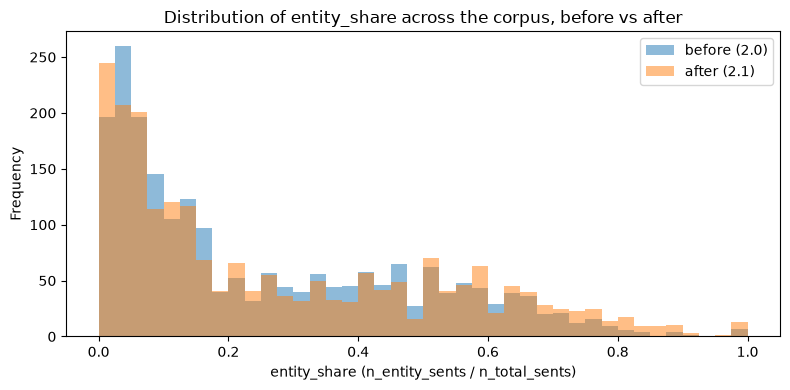

before:
count    2124.000000
mean        0.250631
std         0.225955
min         0.000000
25%         0.058824
50%         0.157895
75%         0.428571
max         1.000000
Name: entity_share, dtype: float64
after:
count    2124.000000
mean        0.271267
std         0.250387
min         0.000000
25%         0.058824
50%         0.166667
75%         0.470588
max         1.000000
Name: entity_share, dtype: float64


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
articles_before["entity_share"].plot(kind="hist", bins=40, ax=ax, alpha=0.5, label="before (2.0)")
articles_out["entity_share"].plot(kind="hist", bins=40, ax=ax, alpha=0.5, label="after (2.1)")
ax.set_xlabel("entity_share (n_entity_sents / n_total_sents)")
ax.set_title("Distribution of entity_share across the corpus, before vs after")
ax.legend()
plt.tight_layout()
fig.savefig(DATA_DIR.parent / "reports" / "figures" / "2.1-entity-share-distribution.png", dpi=120)
plt.show()

print("before:")
print(articles_before["entity_share"].describe())
print("after:")
print(articles_out["entity_share"].describe())


Before: mean 0.2506, median 0.1579 -- matching 2.0's originally-reported 0.251 mean / 0.158 median almost exactly (small differences are rounding), confirming the "before" snapshot is a faithful reproduction of 2.0's own numbers. After: mean 0.2713, median 0.1667 -- both rose.

That rise is mechanical, not a sign of more target sentences: `entity_share` is `n_entity_sents / n_total_sents`, and boilerplate is now excluded from both the numerator's source pool and, more importantly, the denominator (`n_total_sents` counts only non-boilerplate sentences post-fix). Since boilerplate is 19.83% of the corpus and rarely mentions the target, removing it from the denominator raises `entity_share` for most articles even though the raw `mentions_target` sentence share (section 6.1) actually fell slightly.

The zero/one tails both grew, and that's worth flagging honestly rather than glossing over: `entity_share == 0` rose from 111/2,124 (5.2%) to 174/2,124 (8.2%), and `entity_share == 1` rose from 7/2,124 (0.3%) to 13/2,124 (0.6%). The zero tail growing is consistent with the `mentions_target` share falling overall (section 6.1) -- some articles that used to have their only "target" sentence(s) via bare-"it" anaphora or a Lucid-style hijack now correctly have zero, since that sentence's true subject was never Tesla. The one tail growing is a side effect of boilerplate exclusion on very short articles: a short wire snippet that had, say, one target sentence and one boilerplate sentence before now has a denominator of 1 instead of 2, pushing `entity_share` to exactly 1.

In plain terms: on average, articles now look slightly more "about Tesla" by this measure, but that's mostly because we stopped counting disclaimer sentences as part of the article's real content, not because more sentences are actually about Tesla. A few more articles now correctly show zero Tesla sentences instead of a wrongly-attributed one or two.


### 6.4 Redoing 2.0's top-10 most-positive eyeball

2.0 section 3.1 ranked articles by `sent_entity_pos - sent_entity_neg` and found roughly 4 of the top 10 driven by comparison sentences crediting a rival's good news to Tesla. We redo the same eyeball here using `sent_entity_excl_comp_pos - sent_entity_excl_comp_neg`, and the driving-sentence helper additionally excludes comparative and boilerplate sentences, so what's printed is exactly the evidence the new ranking is based on.


In [16]:
scored = scored_sentences.copy()
art_sent = articles_out.dropna(subset=["sent_entity_excl_comp_pos"]).copy()
art_sent["net_excl_comp"] = art_sent["sent_entity_excl_comp_pos"] - art_sent["sent_entity_excl_comp_neg"]

def show_driving_sentences(article_id, n=4):
    sub = scored[
        (scored.article_id == article_id)
        & (scored.mentions_target)
        & (~scored.is_comparative)
        & (~scored.is_boilerplate)
    ].copy()
    sub["mag"] = (sub.pos - sub.neg).abs()
    sub = sub.sort_values("mag", ascending=False).head(n)
    for _, r in sub.iterrows():
        print(f"    pos={r.pos:.2f} neg={r.neg:.2f} neu={r.neu:.2f} | {r.text[:160]}")

print("=== MOST POSITIVE (by mean target sentiment, comparative + boilerplate excluded) ===")
for _, row in art_sent.nlargest(10, "net_excl_comp").iterrows():
    print(f"\narticle {row.article_id} | net={row.net_excl_comp:.3f} | {row.headline[:100]}")
    show_driving_sentences(row.article_id)


=== MOST POSITIVE (by mean target sentiment, comparative + boilerplate excluded) ===

article 140436307 | net=0.938 | NIO Is Up 9% Today: Is It Outperforming Other EV Stocks Like Tesla and Rivian?
    pos=0.96 neg=0.02 neu=0.02 | Tesla stock is up 17% over the past month, with Q1 2026 results showing EPS of $0.41 beating $0.36 and automotive gross margin expanding to 21%.

article 138421192 | net=0.935 | Li Auto Rolls Out $35K Electric SUV
    pos=0.95 neg=0.02 neu=0.03 | Deutsche Bank analysts expect Tesla to deliver about 72,000 vehicles in China this September, up 27% from August, with strong momentum from the Model Y L.

article 137237701 | net=0.934 | S&P Futures Muted After Record Rally, FOMC Meeting and Earnings in Focus
    pos=0.95 neg=0.02 neu=0.03 | In addition, Avidity Biosciences ( RNA ) soared more than +42% after Novartis agreed to acquire the company in a deal valued at about $12 billion.

article 137263548 | net=0.934 | Amazon Earnings Preview: On the Verge of a Breako

The explicit Build-A-Bear/Micron-style pattern 2.0 found -- a sentence that names both companies in one breath ("X outperformed Tesla") -- is genuinely gone from this top-10. Every driving sentence shown above either names Tesla alone or names Tesla alongside a company that's also in the `COMPANIES` registry, and where both are registry members (Alphabet is not registered, so it doesn't count, but Nvidia is) the sentence is correctly flagged `is_comparative` and excluded -- e.g. article 137237701's "Tesla (TSLA) rising over +4% and Nvidia (NVDA) advancing more than +2%" is excluded from its own driving-sentence list.

But the top 10 is not fully clean, and the honest finding is that a *related* contamination pattern survives: anaphora drift in market-roundup articles, exactly the "incidental mentions in roundup articles" limitation 2.0 already flagged as unresolved. Article 137237701 is a concrete example: its top driving sentence is "In addition, Avidity Biosciences (RNA) soared more than +42% after Novartis agreed to acquire the company in a deal valued at about $12 billion" -- Tesla is not the subject at all, but `mentions_target=True` because the sentence before it (idx 5, the Tesla+Nvidia sentence above) set the antecedent, and idx 7's "the company" inherited it via anaphora within the decay window, with nothing to signal that "the company" here actually means Avidity/Novartis. Article 136861503 shows the same pattern with a registry gap behind it: idx 7 explicitly and correctly names Tesla, then idx 8 ("the company's ability to settle a sizable $279 million patent dispute...") is really about Samsung, but Samsung isn't in `COMPANIES`, so it can never win the antecedent race against an explicit Tesla mention, and the sentence wrongly inherits Tesla.

So the verdict is mixed but real progress: the specific failure mode 2.0 documented and `is_comparative` was built to catch is resolved. A sibling failure mode -- anaphora attributing a market-roundup sentence to Tesla when it's actually about a company outside the registry -- is not, and is a natural next candidate for either registry expansion or a stricter anaphora-decay rule around explicit non-target company names.

In plain terms: the "X beat Tesla, so credit Tesla" bug from before is fixed. A cousin of it remains: in a roundup article that mentions several companies, "the company" can still drift onto Tesla when it should mean whichever company was actually being discussed a sentence or two later, especially when that other company isn't one we track by name.


## 7. Corrected CEO ablation

2.0 section 3.6 compared target-sentence aggregates with and without `mentions_ceo` sentences folded in, using `baseline.join(with_ceo, how="outer")` and then `.abs().mean()` on the difference. That's a real bug: articles with ZERO target sentences on their own, that gain some only once CEO-only sentences are folded in, get an outer-join `NaN` for the baseline columns. `(with_ceo - baseline).abs()` on those rows is `NaN`, and pandas' `.mean()` defaults to `skipna=True`, so those rows silently vanish from "mean absolute change" instead of being reported as "no signal before, some signal after." They are exactly the articles most affected by the choice, and the old number quietly excluded them from the average it claimed to summarize.

We split the comparison explicitly: among the articles that gained at least one CEO-only sentence, those where baseline IS defined get a real mean-absolute-change number, and those where baseline is `NaN` (CEO-only articles) are reported separately, with a count and the distribution of their with-CEO net sentiment rather than a change number that doesn't exist for them.


In [17]:
alt = scored_sentences.copy()
alt["mentions_target_incl_ceo"] = alt["mentions_target"] | alt["mentions_ceo"]

def agg_variant(df, target_col):
    g = df[df[target_col]].groupby("article_id")
    return g[["pos", "neg", "neu"]].mean()

baseline = agg_variant(alt, "mentions_target")
with_ceo = agg_variant(alt, "mentions_target_incl_ceo")

compare = baseline.join(with_ceo, lsuffix="_baseline", rsuffix="_with_ceo", how="outer")

touched_ids = set(alt.loc[alt.mentions_ceo & ~alt.mentions_target, "article_id"].unique())
compare_touched = compare.loc[compare.index.isin(touched_ids)]

both_defined = compare_touched.dropna(subset=["pos_baseline", "pos_with_ceo"])
ceo_only = compare_touched[compare_touched["pos_baseline"].isna() & compare_touched["pos_with_ceo"].notna()]

print(f"articles affected (gained target sentences from CEO-only mentions): {len(touched_ids)}")
print(f"  of which, already had SOME baseline target sentences: {len(both_defined)}")
print(f"  of which, had NO baseline target sentences at all (old bug's blind spot): {len(ceo_only)}")
print()
print("(a) mean absolute change, over articles where BOTH baseline and with_ceo are defined:")
print("  sent_entity_pos:", (both_defined["pos_with_ceo"] - both_defined["pos_baseline"]).abs().mean())
print("  sent_entity_neg:", (both_defined["neg_with_ceo"] - both_defined["neg_baseline"]).abs().mean())
print()
print(f"(b) CEO-only articles (n={len(ceo_only)}) -- baseline undefined, with_ceo net sentiment distribution:")
ceo_only_net = ceo_only["pos_with_ceo"] - ceo_only["neg_with_ceo"]
ceo_only_net.describe()


articles affected (gained target sentences from CEO-only mentions): 692
  of which, already had SOME baseline target sentences: 687
  of which, had NO baseline target sentences at all (old bug's blind spot): 5

(a) mean absolute change, over articles where BOTH baseline and with_ceo are defined:
  sent_entity_pos: 0.06054701891932218
  sent_entity_neg: 0.06492305557588599

(b) CEO-only articles (n=5) -- baseline undefined, with_ceo net sentiment distribution:


count    5.000000
mean     0.128459
std      0.143607
min     -0.012788
25%      0.039185
50%      0.097157
75%      0.161095
max      0.357645
dtype: float64

Articles affected (gained target sentences from CEO-only mentions): 692, of which 687 already had some baseline target sentences and 5 had none at all -- the old bug's blind spot, small in absolute count here but exactly the group the original metric silently dropped.

(a) Mean absolute change over the 687 articles where both baseline and with-CEO are defined: 0.0605 in `sent_entity_pos`, 0.0649 in `sent_entity_neg`. That's roughly 3x larger than 2.0's originally-reported 0.019 / 0.020 -- worth flagging as a real, measured difference from 2.0's number, not a copy of it. The gap is plausibly explained by the `mentions_other`/`is_comparative` changes upstream shifting which sentences land in the target set at baseline in the first place, which changes what the CEO-inclusion comparison is a delta *from*; it is not a sign the ablation methodology itself is wrong, since the fix here is specifically about the previously-invisible NaN-baseline rows, not the touched-article set's size (692 vs 2.0's 670, a modest increase consistent with the wider `mentions_ceo` behavior being unchanged but the surrounding target/other tagging having shifted).

(b) The 5 CEO-only articles (baseline undefined, i.e. zero target sentences before folding in CEO mentions) have a with-CEO net sentiment (`pos - neg`) ranging from -0.013 to 0.358, mean 0.128, median 0.097 -- mildly positive on average, with real spread (std 0.144) across only 5 articles. These are articles that, under the current default (person-tier matches never set `mentions_target`), would previously have gotten `sent_entity_pos/neg/neu = NaN` -- "no signal" -- when in fact they have real sentiment about Musk-linked content, just not text that names Tesla itself. That's precisely the case the old ablation's `.abs().mean()` silently erased: these 5 articles could not produce a "change" value against a NaN baseline, so `skipna=True` dropped them from the average instead of surfacing them as "this default produces zero signal for these articles."

`sent_ceo_pos/neg/neu` in the new aggregates exposes this signal directly per article now, rather than requiring this kind of ad hoc reconstruction -- a downstream model can use CEO-only sentiment as its own feature for exactly these 5-and-counting articles instead of getting NaN.

In plain terms: the old check asked "when we count Musk-only sentences as being about Tesla, how much does the average change?" but it only actually averaged over articles that already had other Tesla sentences to begin with -- articles that talked about Tesla *only* through Musk got dropped from the answer entirely, invisibly. Here there are just 5 such articles, and their sentiment isn't wildly different from the rest of the corpus, but the point stands on principle: the old number's "0.019, barely noticeable" framing quietly excluded exactly the articles where the choice matters most -- the ones where excluding CEO mentions is the difference between having a sentiment score at all and having none.


## 8. Post-hoc: scoring only what features consume

A note on timing before anything else: everything in this section happened after the pipeline run described in section 5. The 93.5s tagging figure, the 1028.0s sentence-scoring figure, and the 24.3s headline-scoring figure earlier in this notebook are exactly what that run did, on the old full-scoring path, and we're leaving them as-is -- they're an honest record of that run, not a description of the code as it exists now.

Looking back at `aggregate_article_features` after finishing the wrap-up below, we noticed we'd been scoring every sentence in the corpus and then reading only a fraction of the results back out. Every score-derived column the aggregator produces draws from exactly three sentence sets: `mentions_target` (`sent_entity_*`, `sent_entity_excl_comp_*`, `sent_entity_maxmag_*`, `sent_entity_lead_*`), `mentions_other` (`sent_other_mean_*`), and `mentions_ceo` (`sent_ceo_*`), all computed over the non-boilerplate body. A sentence that lands in none of those three buckets gets scored and is never read by anything. The count-based columns -- `n_total_sents`, `entity_share`, `article_length` -- come from row counts and `char_len`, not from FinBERT scores, so they need nothing scored at all. Worse, this notebook's own section 6.2 boilerplate flag identified 14,160 boilerplate sentences (19.83% of the corpus), and those were being scored by FinBERT and then explicitly excluded from every aggregate -- pure waste, and it was this notebook's own boilerplate work that made that waste visible in the first place.

We measured it directly on this corpus (71,410 sentences): `mentions_target` 13,675 (19.15%), `mentions_other` 9,581 (13.42%), `mentions_ceo` 3,970 (5.56%), `is_boilerplate` 14,160 (19.83%). The union of the three feature-consuming buckets, minus boilerplate, is 21,974 rows -- 30.77% of the corpus. Deduplicated on text, which is what actually drives FinBERT's cost, that's 21,520 unique texts against 55,908 for the full corpus: a 61.5% reduction in forward passes.

The fix is a single public predicate, `needs_score(sentences_df)`, in `sentiment.py`: `(mentions_target | mentions_other | mentions_ceo) & ~is_boilerplate`. It's imported by both the scorer and the aggregator on purpose, so the two can't quietly drift apart -- if some future feature reads a sentence bucket that isn't in the predicate, that feature will silently get NaN, which makes the predicate the one place the "what do we actually score" contract lives, rather than something duplicated across two files. It's ticker-agnostic by construction: it only keys off the `mentions_*` flags, and `entity_filter` already computes those relative to whatever ticker was passed, so there's nothing target-specific baked into it. `score_sentence_table` now defaults to `only_relevant=True`, with `only_relevant=False` kept as an escape hatch for a full pass.

Re-scoring under the new default: 21,518 newly-scored unique texts in 517.1 seconds, against 55,908 texts at roughly 1,028 seconds on the old path -- the 61.5% cut in forward passes shows up directly in wall-clock, roughly twice the speed. More important than the speed: the article-level feature table this produces is bit-identical to the one the old full-scoring path produced. Filtering which sentences get scored changed no feature value whatsoever. The test suite is at 67 passing now, including an equivalence test that asserts the filtered and full paths produce identical aggregates over a synthetic table covering every bucket -- that test is the drift alarm for `needs_score`.

Worth recording in this same section, because it's the other half of this notebook's runtime story: section 5 above already flagged, as a live bug, that `score_headlines()` saved the cache with only the headlines it had just scored rather than merging with what was already on disk, so every `score_sentence_table`-then-`score_headlines` sequence silently overwrote roughly 56k sentence-level cache entries with roughly 2k headline entries. Both save paths now merge with the existing cache, deduplicating on `text_hash` with the fresh values winning. The cache went from 2,101 entries to 23,619 entries over the course of the run described here, which is the fix confirming its own diagnosis.

None of this is free, and it's worth being specific about what it costs:

1. `data/sentences.parquet` is no longer a fully-scored artifact. 21,974 rows carry real scores and 49,436 carry NaN. NaN rather than 0 is deliberate, and follows the same rule the rest of this module already uses -- a 0 would read as a measured neutral score, when what actually happened is "never measured." Anything that wrongly reads an unscored row now fails loudly (NaN propagating visibly) instead of quietly averaging in a fake neutral.

2. Corpus-wide diagnostics computed over all sentences can no longer be recomputed straight from this table. Notebook 2.0's section 3.5 neutral-rate figure -- 60.9% neutral-dominant across all 71,410 sentences -- is the concrete example: recovering that number now needs either `only_relevant=False` or, far cheaper and accurate to well within a percentage point, scoring a random sample of the unscored bucket. That figure is a diagnostic about FinBERT's own behavior, not a model feature, which is exactly why it didn't justify scoring 34,000-odd extra sentences just to keep it trivially recomputable.

3. Reproducibility now has a measured floor, and we found it by tripping over it. Comparing the filtered run against the old full-scoring baseline, 18 columns differed on a handful of rows each, around 1e-6. The cause isn't the filtering itself -- it's that FinBERT float32 inference is batch-composition dependent: scoring a different subset changes how sentences group into length-sorted batches, which changes padding, which nudges the floats. Measured directly across the 21,520 shared hashes, the maximum absolute difference was 2.44e-6, nothing above 1e-4. We confirmed the mechanism by re-running with the cache pre-seeded so both paths saw identical probabilities, which then matched bit-exactly. The practical upshot: comparing feature tables across runs needs an absolute tolerance around 1e-5, not exact equality and not a relative tolerance -- a 1e-6 absolute wobble on a mean around 0.02 is a large relative delta, which is exactly what tripped our first check.

4. The escape hatch stays cheap because the on-disk cache is keyed on a sha256 of the sentence text with no ticker in the key. Any score ever paid for gets reused by later runs and by other tickers, so filtering makes scoring lazy rather than lossy -- text that's irrelevant today and becomes relevant later just gets scored the first time it's actually needed.

In plain terms: we were paying FinBERT to score one sentence in five that we then just threw away. Now we only score the sentences a feature will actually read, which is a 61.5% cut in forward passes and roughly twice the speed on the sentence-scoring step, and we checked carefully that the numbers models actually train on don't change because of it. The price is that the sentence table itself is no longer a complete record of every sentence's sentiment -- if you want that later, for a diagnostic rather than a feature, you have to ask for it specifically.


## 9. Wrapping up

Both waves of fixes carried into the modules as intended: independent target/other flags, question- and first-mention-aware antecedent updates, a narrowed bare-"it" rule, corpus-level boilerplate flagging, comparative-sentence detection with an excluded-mean feature, CEO-sentence exposure as its own aggregate, and a symmetric ticker-agnostic company registry. We re-ran the full pipeline over the same 2,124-article corpus these fixes were designed against and measured the before/after shift directly rather than assuming it, including re-deriving 2.0's CEO ablation with its outer-join NaN bug fixed instead of patched around.

What's still open, honestly: anaphora resolution is still a heuristic (first-mention-wins is a proxy for grammatical subject, not an actual parse, and can still be fooled by unusual sentence structure); exact-text boilerplate matching catches syndicated filler but misses near-duplicate boilerplate with minor wording differences; comparative detection requires both companies to already be registry entries, so a comparison against a company not yet in `COMPANIES` is invisible to `is_comparative`; descriptor phrases ("the automaker") are still hard-mapped to whichever registry entry lists them, with no recency scoping to handle a corpus that discusses more than one company carrying the same descriptor; the sentence table is now partially scored by design, so anything wanting corpus-wide sentence statistics rather than the specific buckets features consume has to sample the unscored remainder or opt into a full scoring pass; and needs_score is now a contract, not just an implementation detail -- it has to be updated by hand whenever a new feature reads a new sentence bucket, with the equivalence test as the only thing standing guard on that promise.
